# Imports

In [111]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*anndata.*", category=FutureWarning)
plt.rcParams["font.family"] = "Arial"
# - dirs 
from ciim.src.common import base_dir, plots_dir, datasets_all, aging_clock_train_datasets, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, \
        par_simulation, prior_dir

from ciim.src.feature_association.helper import retrieve_sig_stats, get_consensus_net
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation, wrapper_in_silico_single_perturbation, identify_top_tfs
from ciim.src.insilico_perturbation.plots import plot_age_acceleration
from ciim.src.utils.util import get_genesets, get_essential_hallmark
from ciim.src.insilico_perturbation.plots import wrapper_plot_age_acceleration_for_tf_perturbation
from ciim.src.insilico_perturbation.biological_analysis.helper import summarize_pathway_scores
n_jobs = 20


cell_types = ['CD4T', 'CD8T'] #['CD4T', 'CD8T',  'NK', 'MONO']
opengenes_pathways = get_genesets('opengenes')
essential_genes = get_genesets('essential')
essential_hallmark = get_essential_hallmark()
gene_score_shift_col = 'gene_score_shift_log2fc'
value_col= 'mean_diff' #'mean_diff' #'z_score'#'signed_neg_log10_pval'

par = par_simulation

# Single aging TF perturbation

In [2]:
datasets = datasets_all[:2]
if False: # run
    # --- Single TF Perturbation ---
    stats_aging = retrieve_sig_stats(type='bulk', race='both', filter_inconsistent=True)

    perturb_rr_dict = {}
    for cell_type in cell_types:
        tfs = stats_aging[stats_aging['cell_type'] == cell_type]['tf'].unique()
        
        par['perturbation_mode'] = 'overexpression'
        if 'tfs' in par:
            del par['tfs']
        perturb_rr = wrapper_in_silico_single_perturbation(tfs=tfs, par=par, n_jobs=n_jobs, cell_types=[cell_type], datasets=datasets)
        perturb_rr_dict[cell_type] = perturb_rr

    age_shift_mean_store = []
    for cell_type, perturb_rr in perturb_rr_dict.items():
        age_shift_mean = perturb_rr.groupby(['cell_type','dataset', 'tf'])['age_shift'].apply(lambda x: x['age_shift'].mean()).reset_index(name='mean_diff')
        age_shift_mean_store.append(age_shift_mean)
    age_shift_mean = pd.concat(age_shift_mean_store)
    stats_aging = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])[['tf', 'cell_type', 'trend']]
    age_shift_mean = age_shift_mean.merge(stats_aging, on=['tf', 'cell_type'], how='left')
    age_shift_mean.to_csv(f"{save_dir}/perturbation/single_aging_tf_age_shift_mean.csv", index=False)

    score_shift_summary = summarize_pathway_scores(perturb_rr, cols=['cell_type', 'dataset', 'tf'])
    score_shift_summary.to_csv(f"{save_dir}/perturbation/single_aging_tf_pathway_score_shift.csv", index=False)
else:
    age_shift_mean = pd.read_csv(f"{save_dir}/perturbation/single_aging_tf_age_shift_mean.csv")
    score_shift_summary = pd.read_csv(f"{save_dir}/perturbation/single_aging_tf_pathway_score_shift.csv")

age_shift_mean.head()

,cell_type,dataset,tf,mean_diff,trend
0,CD4T,data1,AHR,0.054157,Increase in aging
1,CD4T,data1,ARHGAP35,-1.831377,Increase in aging
2,CD4T,data1,ARID5B,-1.042753,Increase in aging
3,CD4T,data1,BACH2,-32.296655,Decrease in aging
4,CD4T,data1,BATF,-3.332738,Increase in aging


## Check the normality of age shift

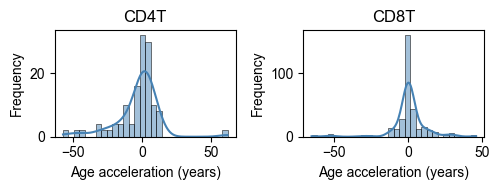

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique cell types
cell_types = age_shift_mean['cell_type'].unique()
n = len(cell_types)

# Determine subplot grid size
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2))
axes = axes.flatten()  # Flatten in case of 2D axes array

for i, cell_type in enumerate(cell_types):
    df = age_shift_mean[age_shift_mean['cell_type'] == cell_type].copy()
    
    ax = axes[i]

    sns.histplot(df['mean_diff'], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(cell_type)
    ax.set_xlabel('Age acceleration (years)')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Significance of age acceleration per TF

In [4]:
# - normalized significance
from scipy.stats import norm

age_shift_mean['z_score'] = age_shift_mean.groupby('cell_type')['mean_diff'].transform(
    lambda x: (x - x.mean()) / x.std()
)

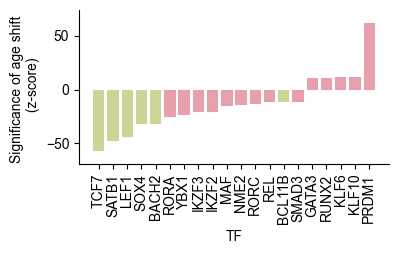

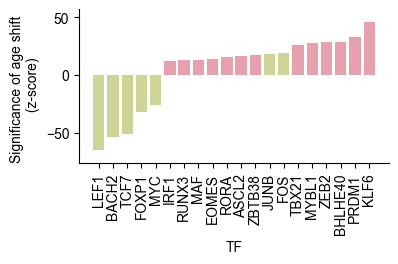

In [6]:
features = None
top_n=20

for cell_type in cell_types:
    age_shift_mean_t = age_shift_mean[age_shift_mean['cell_type'] == cell_type]

    top_tfs = identify_top_tfs(age_shift_mean_t, value_col=value_col, top_n=top_n)
    age_shift_mean_t = age_shift_mean_t[age_shift_mean_t['tf'].isin(top_tfs)].copy()
    age_shift_mean_t['tf'] = pd.Categorical(age_shift_mean_t['tf'], categories=top_tfs, ordered=True)

    aa = wrapper_plot_age_acceleration_for_tf_perturbation(age_shift_mean_t, 
                                            value_col=value_col, 
                                            top_n=top_n,
                                            figsize=(4, 2))
    # plt.legend().remove()
    plt.title(f"", pad=15, weight='bold')
    plt.savefig(f"{plots_dir}/aging_tf_perturbation_{cell_type}.png", bbox_inches='tight', dpi=300, transparent=True)

## Aging trends: verification

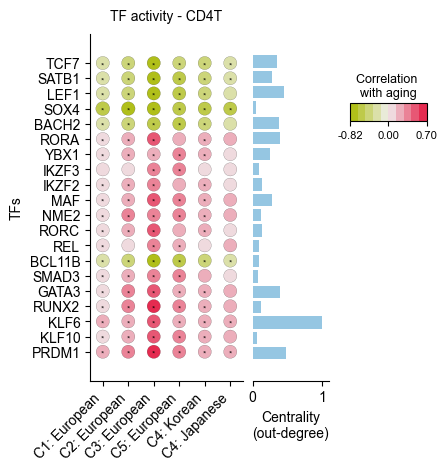

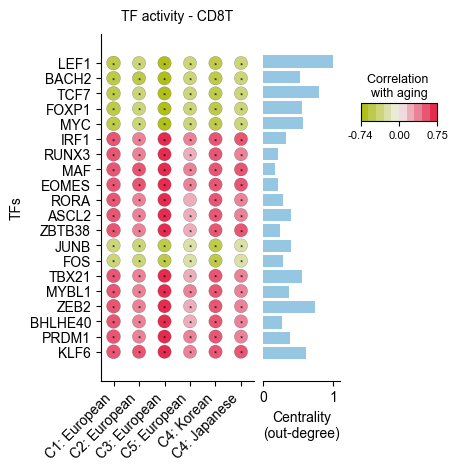

In [9]:
for cell_type in cell_types:
    age_shift_mean_t = age_shift_mean[age_shift_mean['cell_type'] == cell_type].copy()
    top_tfs = identify_top_tfs(age_shift_mean_t, value_col=value_col, top_n=top_n)
    
    

    # median_abs = df_cell.groupby('tf')[value_col].apply(lambda x: x.abs().median())

    # Keep only top TFs
    age_shift_mean_t = age_shift_mean_t[age_shift_mean_t['tf'].isin(top_tfs)].copy()

    # Sort TFs by signed mean_diff for plotting
    tf_order = age_shift_mean_t.groupby('tf')[value_col].mean().sort_values().index
    age_shift_mean_t['tf'] = pd.Categorical(age_shift_mean_t['tf'], categories=tf_order, ordered=True)
    age_shift_mean_t['tf'].cat.categories

    features = age_shift_mean_t['tf'].cat.categories
    from ciim.src.feature_association.plots import plot_features_vs_datasets
    bb = plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features, feature_type='tf_activity', 
                                sizes=(90, 100), width=4,
                                margins_ax1={'x': 0.1, 'y': 0.1}, margins_ax2={'x': 0.1, 'y': 0.07})
    # plt.suptitle(f"", fontsize=12, weight='bold')
    plt.savefig(f"{plots_dir}/{cell_type}_tf_activity.png", bbox_inches='tight', dpi=300, transparent=True)

## Consistency of the age shift with aging TFs: verification 

In [10]:
# Import dependencies
from ciim.src.feature_association.helper import retrieve_sig_stats

# Get the sign of slope for perturbation analysis
# perturb_rr_sig = perturb_rr[perturb_rr['signed_neg_log10_pval'].abs()>1.4]
perturb_slope_sign = (
    age_shift_mean.groupby(['cell_type', 'tf'])['mean_diff']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'mean_diff': 'slope'})
)


# Get the sign of slope for aging TFs (reference)
stats = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])
aging_slope_sign = (
    stats.groupby(['cell_type', 'tf'])['slope']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'slope': 'slope'})
)

# Cell type-specific overlap
overlap_results = []

for cell_type in cell_types:
    # Subset aging (reference) and perturbation data
    aging_t = aging_slope_sign[aging_slope_sign['cell_type'] == cell_type]
    perturb_t = perturb_slope_sign[perturb_slope_sign['cell_type'] == cell_type]
    # Merge on TFs that are found in both
    merged = aging_t.merge(perturb_t, on='tf', suffixes=('_aging', '_perturb'), how='inner')

    if merged.empty:
        continue

    # Count matches with respect to aging slope
    matched = (merged['slope_aging'] == merged['slope_perturb']).sum()
    total = merged.shape[0]
    fraction_matched = matched / total

    overlap_results.append({
        'cell_type': cell_type,
        'n_ref_tfs': len(aging_t),
        'n_overlap_tfs': total,
        'n_matched': matched,
        'percent_matched': 100*fraction_matched
    })


overlap_df = pd.DataFrame(overlap_results)
overlap_df

,cell_type,n_ref_tfs,n_overlap_tfs,n_matched,percent_matched
0,CD4T,67,67,39,58.208955
1,CD8T,163,163,133,81.595092


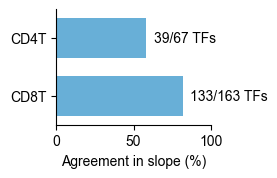

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
figsize=(2, 1.5)
def plot_tf_slope_overlap(overlap_df):
    fig, ax = plt.subplots(figsize=figsize)

    # Plot the bars
    barplot = sns.barplot(
        data=overlap_df,
        x='percent_matched',
        y='cell_type',
        ax=ax,
        width=0.7,
        # palette='viridis'
        color=colors_blind[1],
    )

    # Add text labels directly on the bars
    for bar, (_, row) in zip(barplot.patches, overlap_df.iterrows()):
        width = bar.get_width()
        y_center = bar.get_y() + bar.get_height() / 2
        label = f"{int(row['n_matched'])}/{int(row['n_overlap_tfs'])} TFs"
        ax.text(width + 5, y_center, label, va='center', ha='left', fontsize=10, color='black')

    ax.set_xlim(0, 100)
    ax.set_xlabel('Agreement in slope (%)')
    ax.set_ylabel('')
    sns.despine()
    return fig

# Usage
aa = plot_tf_slope_overlap(overlap_df[overlap_df['cell_type'].isin(['CD4T', 'CD8T', 'MONO', 'NK'])])
plt.savefig(f"{plots_dir}/aging_tf_slope_overlap.png", bbox_inches='tight', dpi=300, transparent=True)

## Pathway scores

In [12]:
cell_type = 'CD8T'
top_n = 20
age_shift_mean_t = age_shift_mean[age_shift_mean['cell_type'] == cell_type].copy()
ordered_tfs = identify_top_tfs(age_shift_mean_t, value_col='mean_diff', top_n=top_n)
print(len(ordered_tfs))

20


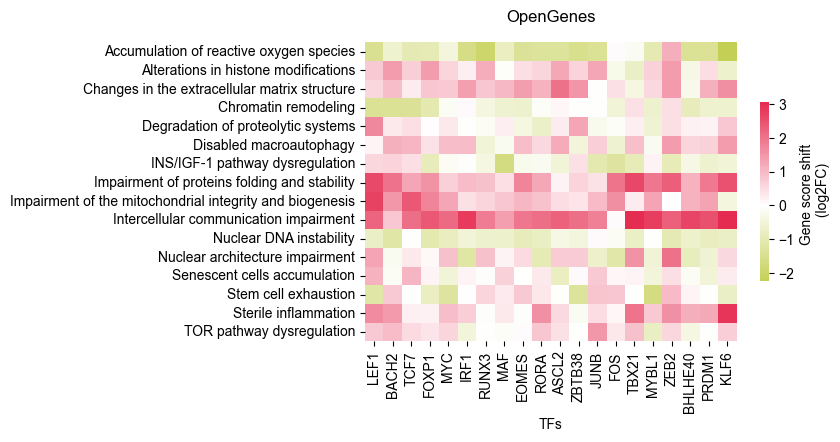

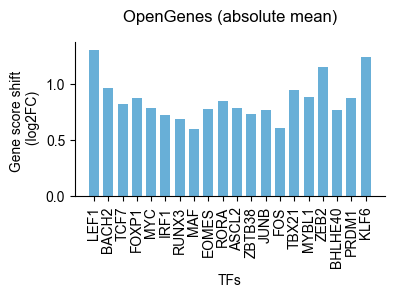

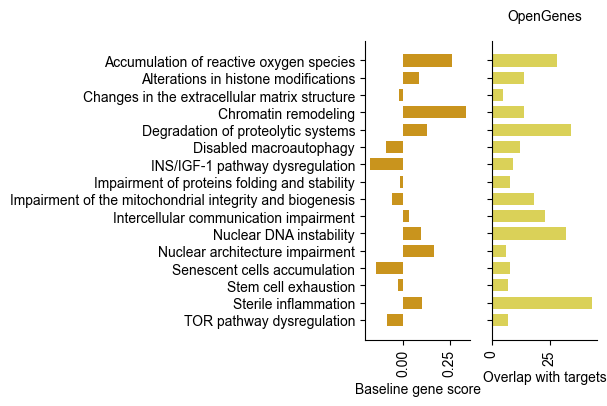

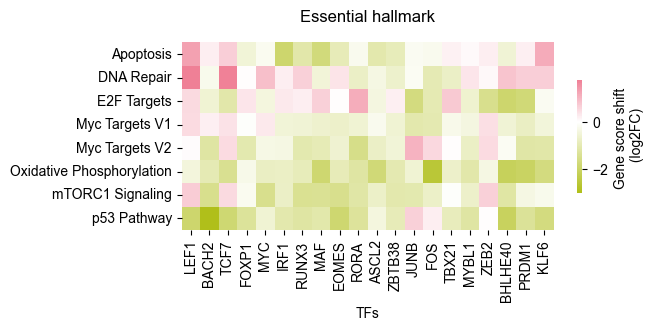

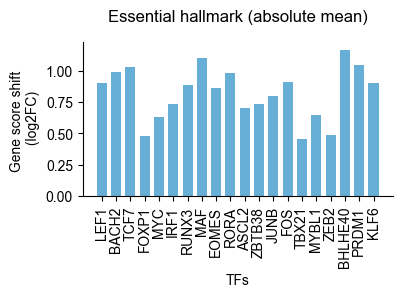

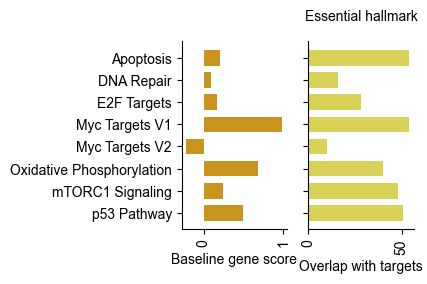

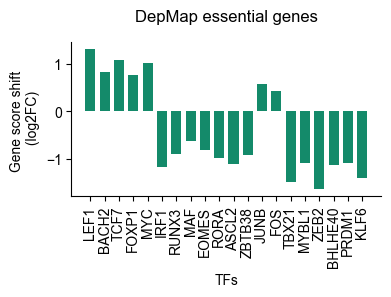

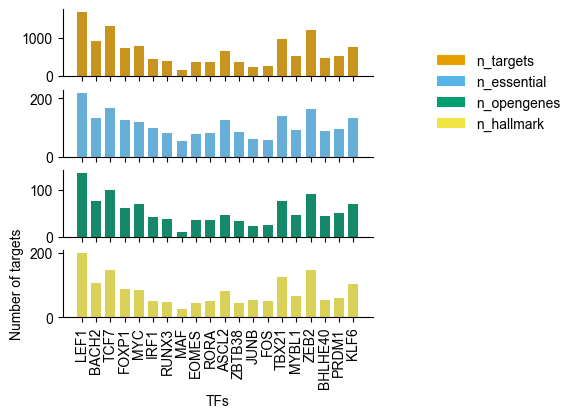

In [18]:
from ciim.src.insilico_perturbation.biological_analysis.helper import plot_all
plot_all(score_shift_summary, cell_type=cell_type, gene_score_shift_col=gene_score_shift_col, ordered_tfs=ordered_tfs,
        geneshift_opengenes=True, geneshift_hallmark=True, ageshift_depmap=True, overvap_risky_genes=True)

### Disease

In [34]:
df = pd.read_csv(f'{base_dir}/prior/disease_gene_association.csv')
df.sort_values('score')

,diseaseId,targetId,score,evidenceCount,disease_name
619944,EFO_0002617,ENSG00000114742,0.000910,1,NaN
621301,EFO_0002617,ENSG00000166478,0.000913,1,NaN
619017,EFO_0002617,ENSG00000001629,0.000913,1,NaN
619419,EFO_0002617,ENSG00000089737,0.000929,1,NaN
619749,EFO_0002617,ENSG00000108039,0.000937,1,NaN
...,...,...,...,...,...
2915921,MONDO_0010526,ENSG00000102393,0.893007,2669,NaN
2694317,MONDO_0007947,ENSG00000166147,0.896680,10059,NaN
270641,EFO_0000538,ENSG00000092054,0.898453,4653,NaN
2923414,MONDO_0010602,ENSG00000185010,0.908495,3569,NaN


# Pathway genes perturbation

In [ ]:
grn = get_consensus_net(cell_type=cell_type)

In [39]:
for key in essential_hallmark.keys():
    if 'myc' in key.lower():
        print(key)

Myc Targets V1
Myc Targets V2


In [132]:
cell_type = 'CD8T'
target_pathway = 'mTORC1 Signaling' #'mTORC1 Signaling' Myc Targets V1
tf_selection_type = 'top_tfs' #  'top_tfs', 'top_enriched_tfs'

pathways = get_genesets()
pathway_genes = pathways[target_pathway]
grn_pathway = grn[grn['target'].isin(pathway_genes)]

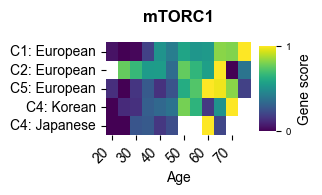

In [113]:
from ciim.src.feature_association.plots import plot_feature_values_all_datasets

datasets = datasets = [d for d in datasets_all if d != 'data12']

fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.2))

plot_feature_values_all_datasets(cell_type, feature=target_pathway, feature_type='gene_score', type='bulk', datasets=datasets, show_cbar=True, ax=ax,
                                    show_ylabels=True)


ax.set_title(f'{surrogate_names[target_pathway]}', pad=15, weight='bold')
plt.savefig(f'{plots_dir}/{target_pathway}_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)

In [114]:
if False:
    from ciim.src.utils.util import get_genesets
    terms = []
    for term in pathways.keys():
        if ('mtor' in term.lower()) | ('ampk' in term.lower()):
            print(term, len(pathways[term]))
            terms.append(term)
    pathways = {k: pathways[k] for k in terms}

## Top regulators of the pathway genes: overall regualtors

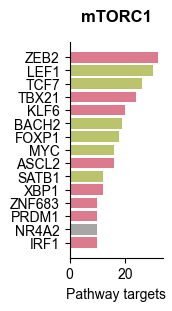

In [120]:
tf_counts = grn_pathway['source'].value_counts().sort_values(ascending=False)
tf_counts_top = tf_counts.head(15).reset_index()  # Limit to top 20 TFs for clarity

stats_aging = retrieve_sig_stats(cell_type=cell_type).drop_duplicates(subset=['cell_type', 'tf', 'trend']).reset_index(drop=True)[['tf', 'trend']]

tf_counts_top = tf_counts_top.merge(stats_aging, left_on='source', right_on='tf', how='left').fillna('Inconsistent')
tf_counts_top['trend'] = pd.Categorical(
    tf_counts_top['trend'],
    categories=palette_trend.keys(),
    ordered=True
)
# Plot

fig, ax = plt.subplots(figsize=(1.2, 2.8))
tf_counts_top = tf_counts_top.sort_values('count', ascending=True)

sns.barplot(
        data=tf_counts_top,
        y='source',
        x='count',
        hue='trend',
        color=colors_blind[2],
        palette=palette_trend,
        edgecolor='black',
        linewidth=0.01,  
        alpha=.7,
        ci=None,
        ax=ax
    )
ax.margins(y=.05)
# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Pathway targets')
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
# ax.legend(loc=[1.05, 0.5], title='Trend',frameon=False, markerscale=1)
ax.get_legend().remove()
ax.set_title(f'{surrogate_names[target_pathway]}', pad=15, weight='bold')

plt.savefig(f'{plots_dir}/tf_counts_{target_pathway}.png', bbox_inches='tight', dpi=300, transparent=True)


## To regulators of the given pathway genes: enriched regulators

In [121]:
from scipy.stats import fisher_exact

# All TFs in the GRN
all_tfs = grn['source'].unique()

# Set of all targets and pathway targets
all_targets = set(grn['target'])
pathway_targets = set(pathway_genes) & all_targets  # keep only known targets

results = []

for tf in all_tfs:
    tf_targets = set(grn.loc[grn['source'] == tf, 'target'])

    a = len(tf_targets & pathway_targets)                     # TF → pathway target
    b = len(tf_targets - pathway_targets)                     # TF → non-pathway target
    c = len(pathway_targets - tf_targets)                     # other TFs → pathway target
    d = len((all_targets - pathway_targets) - (tf_targets - pathway_targets))  # other TFs → non-pathway

    # Skip TFs with no target or zero counts to avoid math errors
    if (a + b + c + d) == 0 or (a + b == 0) or (c + d == 0):
        continue

    # Fisher's exact test
    oddsratio, pval = fisher_exact([[a, b], [c, d]], alternative='greater')  # test for over-representation

    results.append({
        'TF': tf,
        'n_pathway_targets': a,
        'n_total_targets': a + b,
        'odds_ratio': oddsratio,
        'pval': pval
    })

# Convert to DataFrame
df_enrich = pd.DataFrame(results)

# Adjust for multiple testing (optional)
from statsmodels.stats.multitest import multipletests
df_enrich['pval_adj'] = multipletests(df_enrich['pval'], method='fdr_bh')[1]

# Sort by significance
df_enrich = df_enrich[df_enrich['pval_adj'] < 0.05]
df_enrich = df_enrich.sort_values('pval')
df_enrich

,TF,n_pathway_targets,n_total_targets,odds_ratio,pval,pval_adj
83,NR4A2,10,81,7.21275,0.00001,0.001753


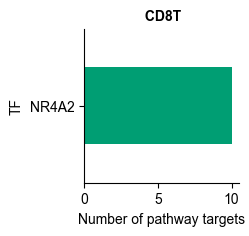

In [117]:
df = df_enrich.sort_values('pval_adj', ascending=True).head(30)
df = df[['TF', 'n_pathway_targets']].set_index('TF')
fig, ax = plt.subplots(figsize=(2, max(2, len(df) * 0.2)))
df.plot(kind='barh', ax=ax, color=colors_blind[2], edgecolor=None)

# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Number of pathway targets')
ax.set_ylabel('TF')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.margins(y=0.1)  # Add margins for better visibility
ax.set_title(f' {cell_type}', weight='bold', fontsize=10)
ax.get_legend().remove()  # Remove legend if not needed

## Run perturbation simulation for different selection of TFs

In [122]:
force_run = False
top_tfs_counts = [2, 5, 7, 10, 15, 20, 25, 50]
if tf_selection_type == 'top_tfs': # general regulators
    tfs_list = tf_counts.index.tolist()
elif tf_selection_type == 'top_enriched_tfs':
    tfs_list = df_enrich.sort_values('pval_adj', ascending=True)['TF'].tolist()
else:
    raise ValueError(f'Unknown tf_selection_type: {tf_selection_type}')

In [123]:
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
from collections import defaultdict

datasets = datasets_all

results = defaultdict(list)

raw_rr_store = []
previous_tfs = []
for n in top_tfs_counts:
    # - get top N TFs regulating the pathway
    tfs = tfs_list[:n]
    par['tfs'] = tfs
    raw_rr = wrapper_in_silico_perturbation(par, n_jobs=n_jobs, cell_types=[cell_type], datasets=datasets_all)
    raw_rr['n'] = n
    raw_rr['added_tfs'] = ', '.join(np.setdiff1d(tfs, previous_tfs))
    previous_tfs = tfs
    raw_rr_store.append(raw_rr)

raw_rr = pd.concat(raw_rr_store).reset_index()


In [126]:
# - summary of pathway gene score shift
score_shift_summary = summarize_pathway_scores(raw_rr, cols=['cell_type', 'dataset', 'n', 'added_tfs'])
target_pathway_score_shift_summary = raw_rr.groupby(['cell_type', 'dataset', 'n'])[target_pathway].mean()[target_pathway]['gene_score_shift'].reset_index()
age_shift_summary = raw_rr.groupby(['cell_type', 'dataset', 'n'])['age_shift'].mean()['age_shift']['age_shift'].reset_index()

age_shift_summary['dataset'] = pd.Categorical(age_shift_summary['dataset'], categories=datasets_all, ordered=True)
target_pathway_score_shift_summary['dataset'] = pd.Categorical(target_pathway_score_shift_summary['dataset'], categories=datasets_all, ordered=True)

age_shift_summary['dataset'] = age_shift_summary['dataset'].apply(lambda name: surrogate_names.get(name, name))
target_pathway_score_shift_summary['dataset'] = target_pathway_score_shift_summary['dataset'].apply(lambda name: surrogate_names.get(name, name))

## Plot age shift and gene score shift per donor

In [127]:
if False: # donor level plot
    from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
    datasets = raw_rr['dataset'].unique()
    n_datasets = len(datasets)
    # for n in raw_rr['n'].unique():
    for n in [10]:
        rr = raw_rr[raw_rr['n'] == n].copy()
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            rr_sub = rr[(rr['cell_type'] == cell_type) & (rr['dataset'] == dataset)].copy()
            df = rr_sub['age_shift']
            df['donor_age'] = rr_sub['donor_age']
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"{cell_type}: {n}", y=1.25, fontsize=12, fontweight='bold')

## Plot the effect of perturbation on aging pathways 

## Plot age shift and the target pathway's gene score shift for different TF selection

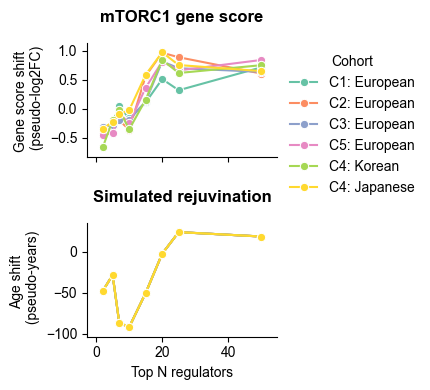

In [133]:
fig, axes = plt.subplots(2, 1, figsize=(4.4, 4), sharex=True, sharey=False)

ax = axes[0]

sns.lineplot(data=target_pathway_score_shift_summary, x='n', y='gene_score_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title(f'{surrogate_names[target_pathway]} gene score', weight='bold', pad=15)
ax.set_ylabel('Gene score shift \n (pseudo-log2FC)')
ax.set_xlabel('Top N regulators')
# ax.set_xticks(top_tfs_counts)
ax.margins(x=0.1, y=0.1)
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Cohort', frameon=False)

ax = axes[1]
sns.lineplot(data=age_shift_summary, x='n', y='age_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title('Simulated rejuvination', weight='bold', pad=15)
ax.set_ylabel('Age shift \n (pseudo-years)')
ax.set_xlabel('Top N regulators')
# ax.set_xticks(top_tfs_counts)
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines

ax.margins(x=0.1, y=0.1)
ax.get_legend().remove()


# plt.suptitle(f'{cell_type}', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/{target_pathway}_{cell_type}_gene_score_shift.png', bbox_inches='tight', dpi=300, transparent=True)

### Per top n regulators perturbation: average over datasets

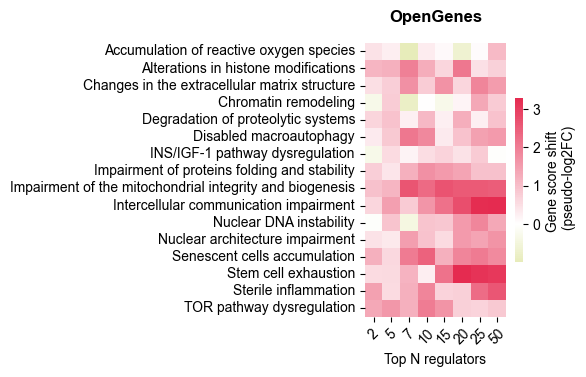

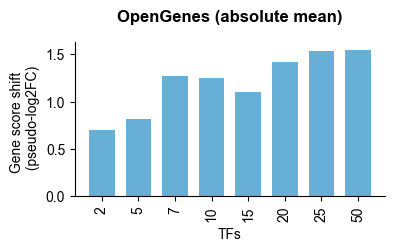

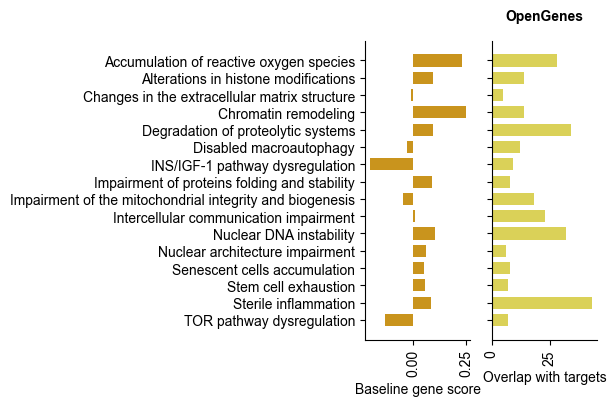

In [130]:
from ciim.src.insilico_perturbation.biological_analysis.helper import plot_pathway_set


def barplot_pathway_counts(df_terms, ax):
    df_terms.plot(kind='barh', 
                  color='skyblue', 
                  width=0.8,
                  edgecolor=None, 
                  ax=ax, 
                  legend=False)
    ax.set_xlabel('Number of genes')
    ax.set_ylabel('')
    ax.set_title('')
    ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines

# --- Prepare data ---
plot_pathway_set(score_shift_summary, 'opengenes', gene_score_shift_col, cell_type, col_name='n', xlabel='Top N regulators', temp_dir=plots_dir)



NameError: name 'heatplot_perturbation_effect' is not defined

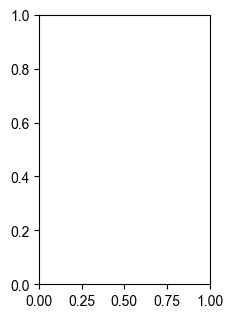

In [131]:
n = 5
df = df_summary_opengenes[df_summary_opengenes['n']==n].copy()
df['dataset'] = df['dataset'].apply(lambda x: surrogate_names[x] if x in surrogate_names else x)

pivot_df = df.pivot_table(index='pathway', columns='dataset', values=gene_score_shift_col)

fig, ax = plt.subplots(figsize=(2.2, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax=ax)

plt.title(f'{target_pathway} ({cell_type}) \n (Top {n} TFs are perturbed)', pad=15, fontsize=12, fontweight='bold')
plt.xlabel('')

# Combinatorial aging TFs perturbation

Text(0.5, 1.25, 'Combinatorial perturbation of aging TFs: CD4T')

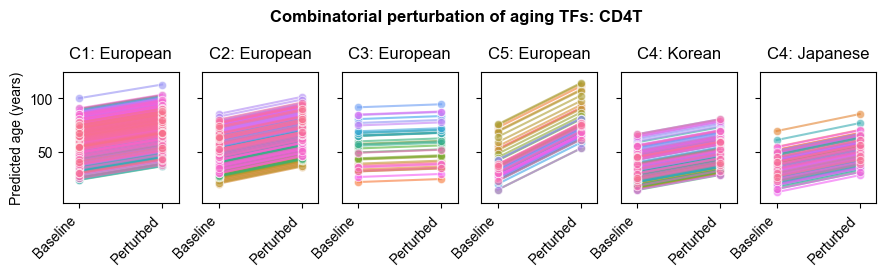

In [ ]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_natural_aging['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_natural_aging[(df_natural_aging['cell_type'] == cell_type) & (df_natural_aging['dataset'] == dataset)].copy()
    df = df['age_shift'].copy()

    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD4T' 'CD8T']


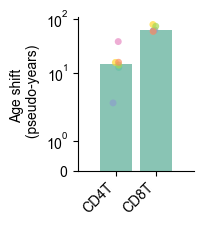

In [427]:
df_mean_aging = df_natural_aging.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_aging['dataset'] = pd.Categorical(df_mean_aging['dataset'], categories=datasets_all, ordered=True)
fig = plot_age_acceleration(df_mean_aging[df_mean_aging['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], 
                            log_y=True, figsize=(1.5, 2),
                            margins=(0.3, 0.4))
plt.legend().remove()
# plt.title('Combinatorial perturbation of aging TFs\n (natural aging mode)', pad=15)

# Combinatorial perturbation of SLE associated aging TFs

In [362]:
# --- SLE TF Perturbation ---
def retrieve_sig_stats_disease(dataset='', feature_type='tf_activity', test_type='unpaired', type='bulk'):
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    return stats_drug[(stats_drug['p_value_adj'] < 0.05) & (stats_drug['age_group'] == 'Both age groups')].copy()

def get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig):
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_disease_sig = stats_disease_sig[['cell_type', 'tf', 'slope_condition']].drop_duplicates()
    stats_both = stats_aging_sig.merge(stats_disease_sig, on=['cell_type', 'tf'], how='inner')
    return stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]


In [ ]:
def run_sle_tf_perturbation():
    print('Running SLE TF perturbation...')
    dataset = 'SLE_European'
    stats_disease_sig = retrieve_sig_stats_disease(dataset=dataset)
    if True: # overlap with aging TFs
        slope_sle = get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig)
    else: # SLE TFs
        slope_sle = stats_disease_sig[['tf','cell_type','slope_condition']].set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]
        print(slope_sle.groupby('cell_type').size())
    slope_sle['slope'] = np.sign(slope_sle['slope']) 
    par_sle = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': None,
        'slope_df': slope_sle,
    }
    df_sle = wrapper_in_silico_perturbation(par_sle, n_jobs=1, cell_types=cell_types, datasets=datasets_all)
    return df_sle
df_sle = run_sle_tf_perturbation()

Running SLE TF perturbation...
Processing: CD4T - data1 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for APICAL SURFACE: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for MYC TARGETS V2: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for NOTCH SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for PANCREAS BETA CELLS: Error calculating gene scores: Privided genes list is empty..

Text(0.5, 1.25, 'Combinatorial perturbation of SLE-affected aging TFs: CD4T')

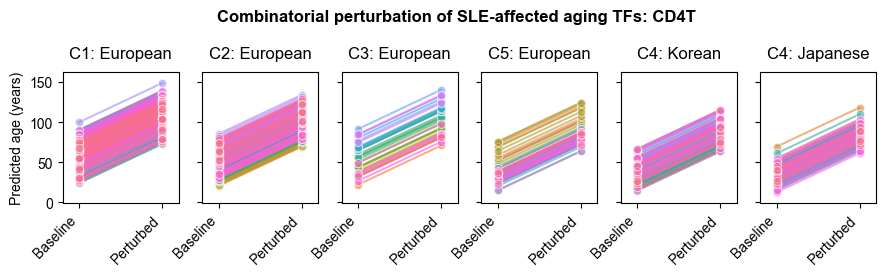

In [ ]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_sle['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_sle[(df_sle['cell_type'] == cell_type) & (df_sle['dataset'] == dataset)].copy()
    df = df['age_shift'].reset_index()
    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of SLE-affected aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD4T' 'CD8T']


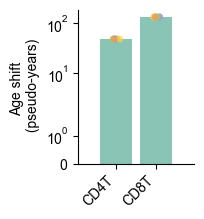

In [ ]:
df_mean_sle = df_sle.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_sle['dataset'] = pd.Categorical(df_mean_sle['dataset'], categories=datasets_all, ordered=True)
fig = plot_age_acceleration(df_mean_sle[df_mean_sle['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], log_y=True,
                               figsize=(1.5, 2),
                            margins=(0.3, 0.4), color=colors_blind[2])
plt.legend().remove()
plt.savefig(f'{plots_dir}/sle_tf_perturbation.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)

# Drug perturbation

In [367]:
# --- Drug Perturbation ---
def retrieve_sig_stats_drug(feature_type='tf_activity', dataset='CXCL9', test_type='paired', type='bulk'):
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    return stats_drug[(stats_drug['p_value_adj'] < 0.05)].copy()

def get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig):
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_drug_sig = stats_drug_sig[['cell_type', 'tf', 'slope_condition', 'comparision']].drop_duplicates()
    stats_both = stats_aging_sig.merge(stats_drug_sig, on=['cell_type', 'tf'], how='inner')
    return stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]

In [383]:
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
def run_perturbation_tf_perturbation():
    print('Running drug perturbation TF perturbation...')
    stats_drug_sig = retrieve_sig_stats_drug(dataset='CXCL9')
    if True: # overlapping TFs
        df_slope = get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig)
    else:
        df_slope = stats_drug_sig.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]
    print(df_slope.groupby(['cell_type', 'comparision']).size())
    df_slope['slope'] = np.sign(df_slope['slope'])
    df_slope.head()
    df_store = []
    # for comparision in tqdm(df_slope['comparision'].unique()):
    for comparision in ['LPS (ctr: RPMI)', 'Ruxolitinib (ctr: LPS)']: #['Ruxolitinib (ctr: LPS)']
        df_slope_c = df_slope[df_slope['comparision'] == comparision].copy()

        par['perturbation_mode'] = None
        par['slope_df'] = df_slope_c

        df_all_c = wrapper_in_silico_perturbation(par, 
                                    n_jobs=n_jobs,
                                    cell_types=cell_types,
                                    datasets=datasets_all #['data1', 'data12']# aging_clock_train_datasets, #['data12'] # datasets_all
                                    )
        df_all_c['comparision'] = comparision
        df_store.append(df_all_c)
    df_all = pd.concat(df_store)
    # df_all.to_csv(f"{save_dir}/perturbation/tf_screen_results_drug_perturbation.csv")
    return df_all
df_perturbation_all = run_perturbation_tf_perturbation()

Running drug perturbation TF perturbation...
cell_type  comparision            
CD4T       LPS (ctr: RPMI)            53
CD8T       LPS (ctr: RPMI)            49
           Ruxolitinib (ctr: LPS)     98
MONO       LPS (ctr: RPMI)            35
           Metformin (ctr: LPS)       35
           Ruxolitinib (ctr: LPS)     20
           Ruxolitinib (ctr: RPMI)    31
NK         LPS (ctr: RPMI)            20
dtype: int64
Processing: CD4T - data1 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for APICAL SURFACE: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for MYC TARGETS V2: E

In [384]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
if False: # donor level plots
    from ciim.src.insilico_perturbation.helper import perform_stat_test
    cell_type = cell_types[0]
    for comparision in df_perturbation_all['comparision'].unique():
        print(comparision)
        datasets = df_perturbation_all['dataset'].unique()
        n_datasets = len(datasets)
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            df = df_perturbation_all[(df_perturbation_all['cell_type'] == cell_type) & (df_perturbation_all['dataset'] == dataset)  & (df_perturbation_all['comparision'] == comparision)].copy()
            df = df['age_shift'].reset_index()
            # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
            # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')
    # comparision = 'Ruxolitinib (ctr: LPS)'
    # datasets = df_all['dataset'].unique()
    # n_datasets = len(datasets)
    # fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
    # for i, dataset in enumerate(datasets):
    #     ax = axes[i] if n_datasets > 1 else axes
    #     df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)  & (df_all['comparision'] == comparision)].copy()

    #     # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    #     # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    #     plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    #     ax.set_title(f"{surrogate_names[dataset]}", pad=10)

    # plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')

['CD4T']
['CD8T']


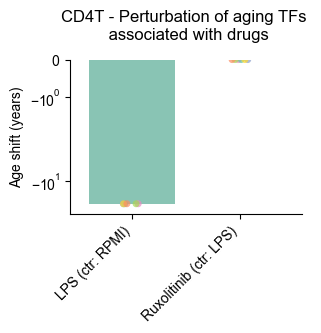

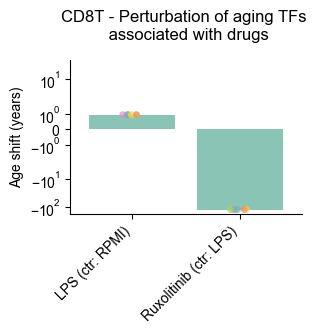

In [ ]:
for cell_type in df_perturbation_all['cell_type'].unique():
    df = df_perturbation_all[df_perturbation_all['cell_type'] == cell_type].copy()
    # df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median().reset_index(name='mean_diff')
    df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
    df_mean['dataset'] = pd.Categorical(df_mean['dataset'], categories=datasets_all, ordered=True)
    plot_age_acceleration(df_mean, x_col='comparision', log_y=True, figsize=(3, 2),
                            margins=(0.1, 0.4))
    plt.legend().remove()
    plt.title(f"{cell_type} - Perturbation of aging TFs \n associated with drugs", pad=15)

# Summary plot of all combinatorial perturbations

In [434]:
df_mean_ruxo = df_perturbation_all[(df_perturbation_all['comparision'] == 'Ruxolitinib (ctr: LPS)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
    

['CD4T']
['CD8T']


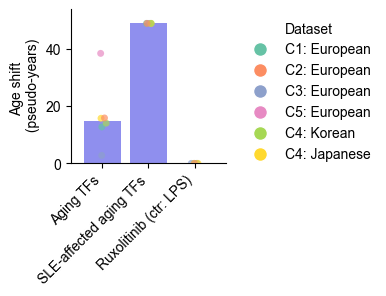

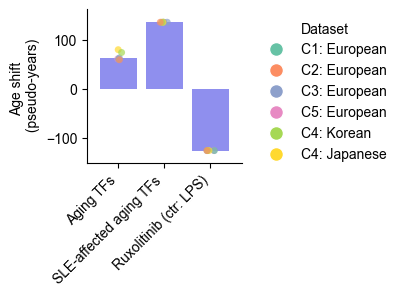

In [435]:
for cell_type in cell_types:
    df_mean_ruxo_c = df_mean_ruxo[(df_mean_ruxo['cell_type'] == cell_type)]
    df_mean_sle_c = df_mean_sle[(df_mean_sle['cell_type'] == cell_type)].copy()
    df_mean_aging_c = df_mean_aging[(df_mean_aging['cell_type'] == cell_type)].copy()

    df_mean_ruxo_c['experiment'] = 'Ruxolitinib (ctr: LPS)'
    df_mean_sle_c['experiment'] = 'SLE-affected aging TFs'
    df_mean_aging_c['experiment'] = 'Aging TFs'

    df_mean = pd.concat([df_mean_aging_c, df_mean_sle_c, df_mean_ruxo_c], ignore_index=True)

    # Normalize by aging TFs
    # df_aging_vals = df_mean[df_mean['experiment'] == 'Aging TFs'][['dataset', 'age_shift']].rename(
    #     columns={'age_shift': 'age_shift_aging'}
    # )

    # df_mean = df_mean.merge(df_aging_vals, on='dataset', how='left')
    # df_mean['age_shift'] = df_mean['age_shift'] / df_mean['age_shift_aging']

    df_mean['dataset'] = pd.Categorical(df_mean['dataset'], categories=datasets_all, ordered=True)

    plot_age_acceleration(df_mean, x_col='experiment', log_y=False, figsize=(2, 2),
                                margins=(0.1, .1))
    plt.savefig(f"{plots_dir}/aging_tf_perturbation_summary_{cell_type}.png", bbox_inches='tight', dpi=300, transparent=True)

In [ ]:
df_perturbation_all['comparision'].unique()

array(['LPS (ctr: RPMI)', 'Ruxolitinib (ctr: LPS)'], dtype=object)

['CD4T' 'CD8T']
['CD4T' 'CD8T']
['CD4T' 'CD8T']
['CD4T' 'CD8T']


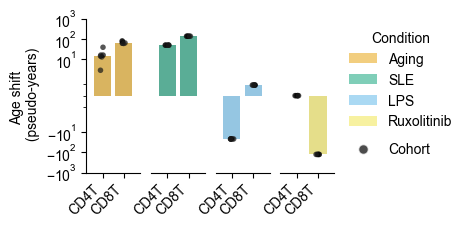

In [562]:
alpha=0.7
color_dataset='black'

df_mean_aging = df_natural_aging.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_sle = df_sle.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_ruxo = df_perturbation_all[(df_perturbation_all['comparision'] == 'Ruxolitinib (ctr: LPS)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_lps = df_perturbation_all[(df_perturbation_all['comparision'] == 'LPS (ctr: RPMI)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()


experiments = ['Aging', 'SLE', 'LPS', 'Ruxolitinib']
dfs = [df_mean_aging, df_mean_sle, df_mean_lps, df_mean_ruxo]
colors = [colors_blind[0], colors_blind[2], colors_blind[1], colors_blind[3]]

# df_combined = pd.concat(dfs, ignore_index=True)
# min_age_shift = df_combined['age_shift'].min()
# max_age_shift = df_combined['age_shift'].max()
# lim = [min_age_shift-20, max_age_shift+20]

fig, axes = plt.subplots(1, len(experiments), figsize=(.8 * len(experiments), 2), sharey=False)


def plot_age_shift(df_all, 
                        x_col='cell_type', 
                        figsize=(3, 3),
                        color='blue',
                        ax=None):
    # If a specific order is given, enforce it
    order = df_all[x_col].unique()
    print(df_all['cell_type'].unique())
    # Calculate median per category
    df_median = df_all.groupby(x_col)['age_shift'].median().reset_index()
    # Plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    df_all['dataset'] = df_all['dataset'].apply(lambda name: surrogate_names.get(name, name))
    sns.stripplot(ax=ax, data=df_all, y='age_shift', x=x_col, hue='dataset',
                  color=color_dataset, alpha=alpha, order=order, s=4)

    sns.barplot(ax=ax, data=df_median, y='age_shift', x=x_col, alpha=alpha, color=color, order=order)
    
    # Axes and labels
    ax.set_ylabel("Age shift \n (pseudo-years)")
    ax.set_xlabel("")
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    
for experiment, df in zip(experiments, dfs):
    
    i = experiments.index(experiment)
    ax = axes[i]
    color = colors[i]
    df['dataset'] = pd.Categorical(df['dataset'], categories=datasets_all, ordered=True)

    plot_age_shift(df, color=color, ax=ax)
    # ax.get_legend().remove()
    # ax.set_ylim(lim)
    
    ax.get_legend().remove()

    # - log x axis
    ax.set_yscale('symlog')
    ax.set_yticks([-1000, -100, -10, 10, 100, 1000])
    # ax.set_yticklabels(['-100', '-10', '10', '100'])
    ax.margins(x=0.2)
    if i != 0:
        ax.set_ylabel('')
        ax.set_yticks([])  # Ensure no ticks are shown
        ax.set_yticklabels([])  # Also clear any existing labels
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
         
def plot_legends(ax):
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D
    legend1_handles = [
        Line2D([0], [0], marker='o', color='w',
            markerfacecolor=color_dataset, alpha=alpha,
            markersize=7, label='Cohort', linestyle='None')
    ]
    legend1 = ax.legend(handles=legend1_handles, title='',
                        bbox_to_anchor=(1.05, 0.15), loc='center left', frameon=False)
    ax.add_artist(legend1)
    legend2_handles = [
        Patch(facecolor=colors[i], edgecolor=None, label=ds, alpha=0.5)
        for i, ds in enumerate(experiments)
    ]
    ax.legend(handles=legend2_handles, title='Condition',
            bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plot_legends(ax)
plt.savefig(f'{plots_dir}/multi_tf_perturbation.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)